In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 600

def disable_ax_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

def dotted_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

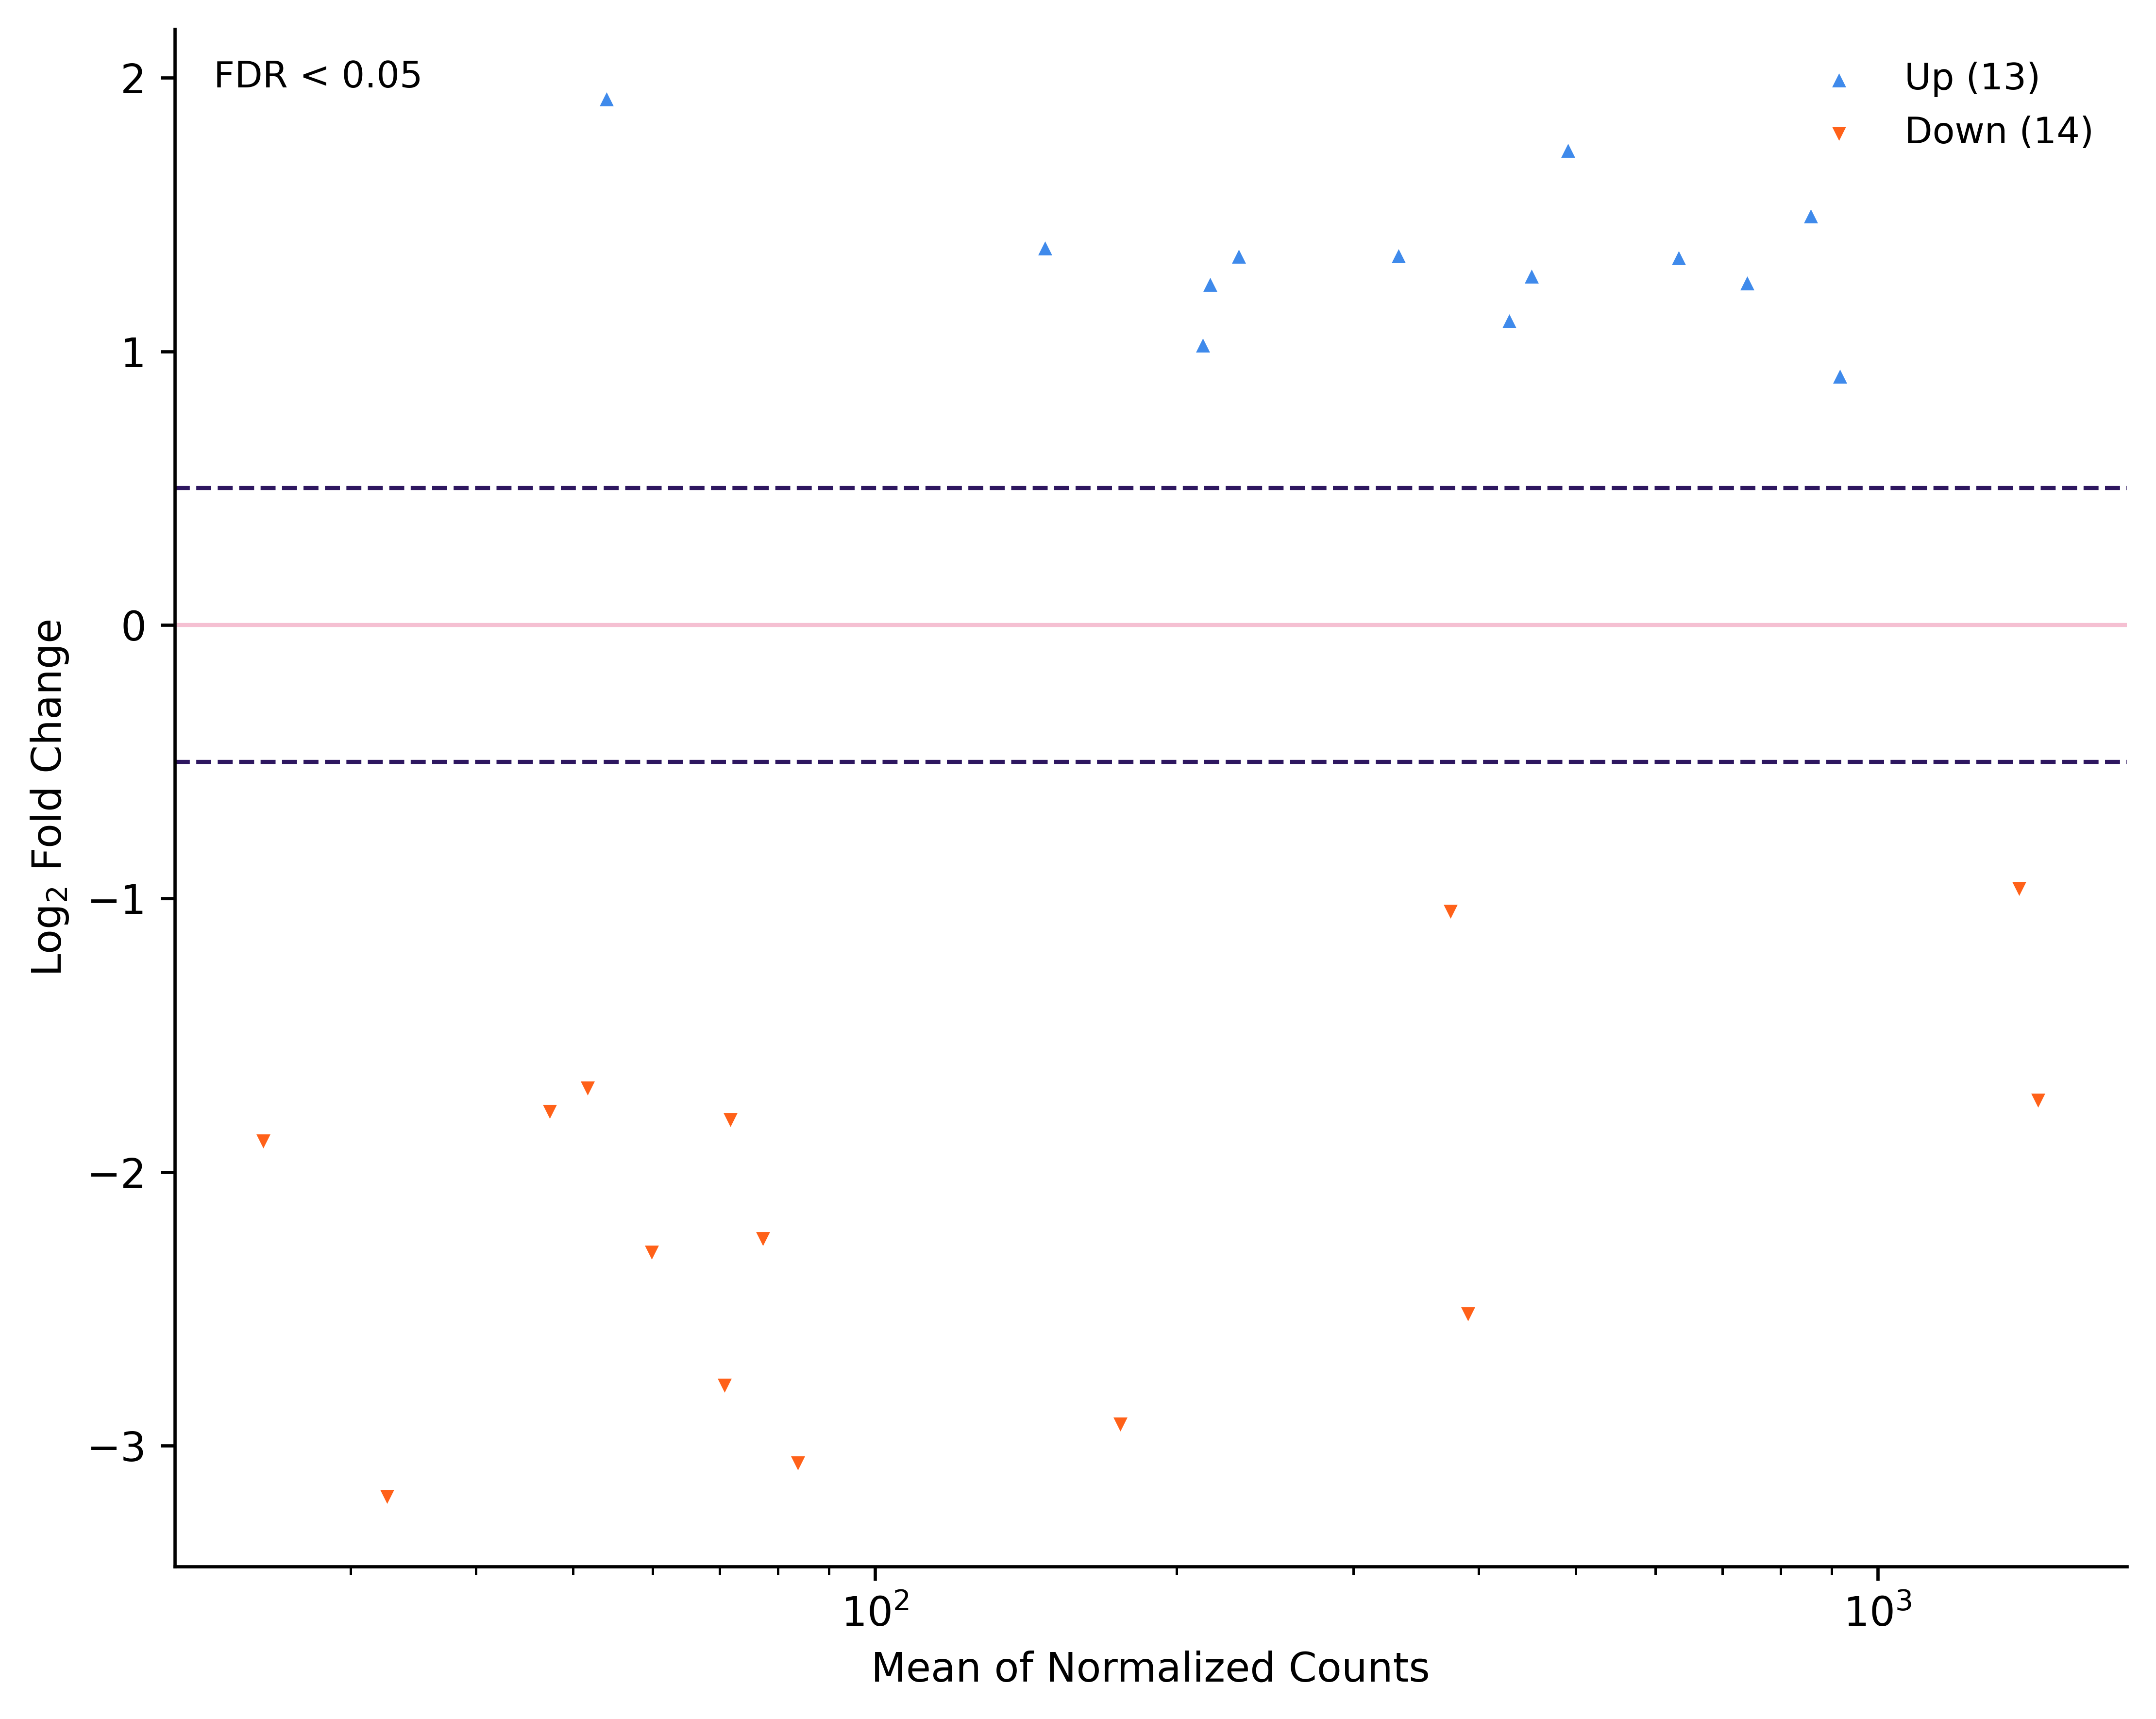

In [5]:
CSV_PATH   = "../data/output/edger_filtered_results.csv"
LFC_THR    = 0.5        # draw horizontal lines at ± this log2FC
FDR_THR    = 1       # significance threshold (if FDR/padj present)
TOP_LABELS = 10         # label this many genes total (split up/down)
POINT_SIZE = 8
# -------------------------------

def bh_adjust(pvals: np.ndarray) -> np.ndarray:
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranks = np.arange(1, n + 1)
    adj = np.empty_like(p)
    adj[order] = np.minimum.accumulate((p[order] * n / ranks)[::-1])[::-1]
    return np.clip(adj, 0, 1)

df = pd.read_csv(CSV_PATH)

# columns
gene_col = "name" if "name" in df.columns else df.columns[0]
lfc_col  = "log2FoldChange" if "log2FoldChange" in df.columns else ("logFC" if "logFC" in df.columns else None)
if lfc_col is None:
    if "foldChange" in df.columns:
        df["__log2FC__"] = np.log2(pd.to_numeric(df["foldChange"], errors="coerce"))
        lfc_col = "__log2FC__"
    else:
        raise ValueError("No log2FC/logFC/foldChange column found.")

padj_col = next((c for c in ["FDR","padj","PAdj"] if c in df.columns), None)
p_col    = next((c for c in ["PValue","pvalue","pval","p"] if c in df.columns), None)

# try to find per-sample normalized counts (columns added at the end in many pipelines)
known_meta = {
    gene_col, lfc_col, "log2FoldChange", "logFC", "foldChange",
    "baseMean","baseMeanA","baseMeanB","lfcSE","stat","PValue","pvalue","PAdj",
    "FDR","padj","falsePos"
}
numdf = df.select_dtypes(include=[np.number]).copy()
norm_cols = [c for c in numdf.columns if c not in known_meta]

if len(norm_cols) >= 2:
    mean_norm = numdf[norm_cols].mean(axis=1)
elif "baseMean" in df.columns:
    mean_norm = pd.to_numeric(df["baseMean"], errors="coerce")
else:
    raise ValueError("Could not find normalized counts (nor baseMean).")

# vectors
genes = df[gene_col].astype(str).to_numpy()
lfc   = pd.to_numeric(df[lfc_col], errors="coerce").to_numpy()

if padj_col:
    padj = pd.to_numeric(df[padj_col], errors="coerce").to_numpy()
elif p_col:
    padj = bh_adjust(pd.to_numeric(df[p_col], errors="coerce").to_numpy())
else:
    padj = np.full(lfc.shape, np.nan)  # no p-values available

# clean
valid = np.isfinite(mean_norm) & np.isfinite(lfc)
if np.isfinite(padj).any():
    valid &= np.isfinite(padj)
mean_norm, lfc, padj, genes = mean_norm[valid], lfc[valid], padj[valid], genes[valid]

# masks
sig = np.isfinite(padj) & (padj < FDR_THR)
up  = sig & (lfc >=  LFC_THR)
dn  = sig & (lfc <= -LFC_THR)
ns  = ~(up | dn)

# plot
fig, ax = plt.subplots(figsize=(7.5, 6))
# all points
ax.scatter(mean_norm[ns], lfc[ns], s=POINT_SIZE, alpha=0.6, linewidths=0, color="#131313")
# overlay significant (different markers; no explicit colors)
ax.scatter(mean_norm[up], lfc[up], s=POINT_SIZE+4, marker="^", alpha=0.9, linewidths=0, label=f"Up ({up.sum()})", color="#2a7de9")
ax.scatter(mean_norm[dn], lfc[dn], s=POINT_SIZE+4, marker="v", alpha=0.9, linewidths=0, label=f"Down ({dn.sum()})", color="#ff5000")

# axes, guides
ax.set_xscale("log")
ax.axhline(0,       ls="-",  lw=1, color="#DE316B4D")
ax.axhline(LFC_THR, ls="--", lw=1, color="#2E1760")
ax.axhline(-LFC_THR,ls="--", lw=1, color="#2E1760")
if np.isfinite(padj).any():
    ax.text(0.02, 0.98, f"FDR < {0.05}", transform=plt.gca().transAxes, va="top", ha="left", fontsize=9)

ax.set_xlabel("Mean of Normalized Counts")
ax.set_ylabel(r"${\rm Log}_{2}$ Fold Change")
# ax.title("MA plot")
ax.legend(frameon=False, fontsize=9, loc="upper right")

# label top genes (split up/down) without changing colors
def label_top(mask, k):
    idx = np.where(mask)[0]
    if idx.size == 0 or k <= 0:
        return
    order = np.lexsort((-np.abs(lfc[idx]), padj[idx]))  # rank: low FDR, large |LFC|
    for i in idx[order[:min(k, idx.size)]]:
        ax.annotate(genes[i], (mean_norm[i], lfc[i]),
                     xytext=(3, 1), textcoords="offset points", fontsize=8)

k_each = TOP_LABELS // 2
# label_top(up, k_each + (TOP_LABELS % 2))
# label_top(dn, k_each)

dotted_spines(ax)

plt.tight_layout()
plt.savefig("../data/output/clean_volcano.png", dpi=300)
plt.savefig("../data/output/clean_volcano.pdf")
plt.show()

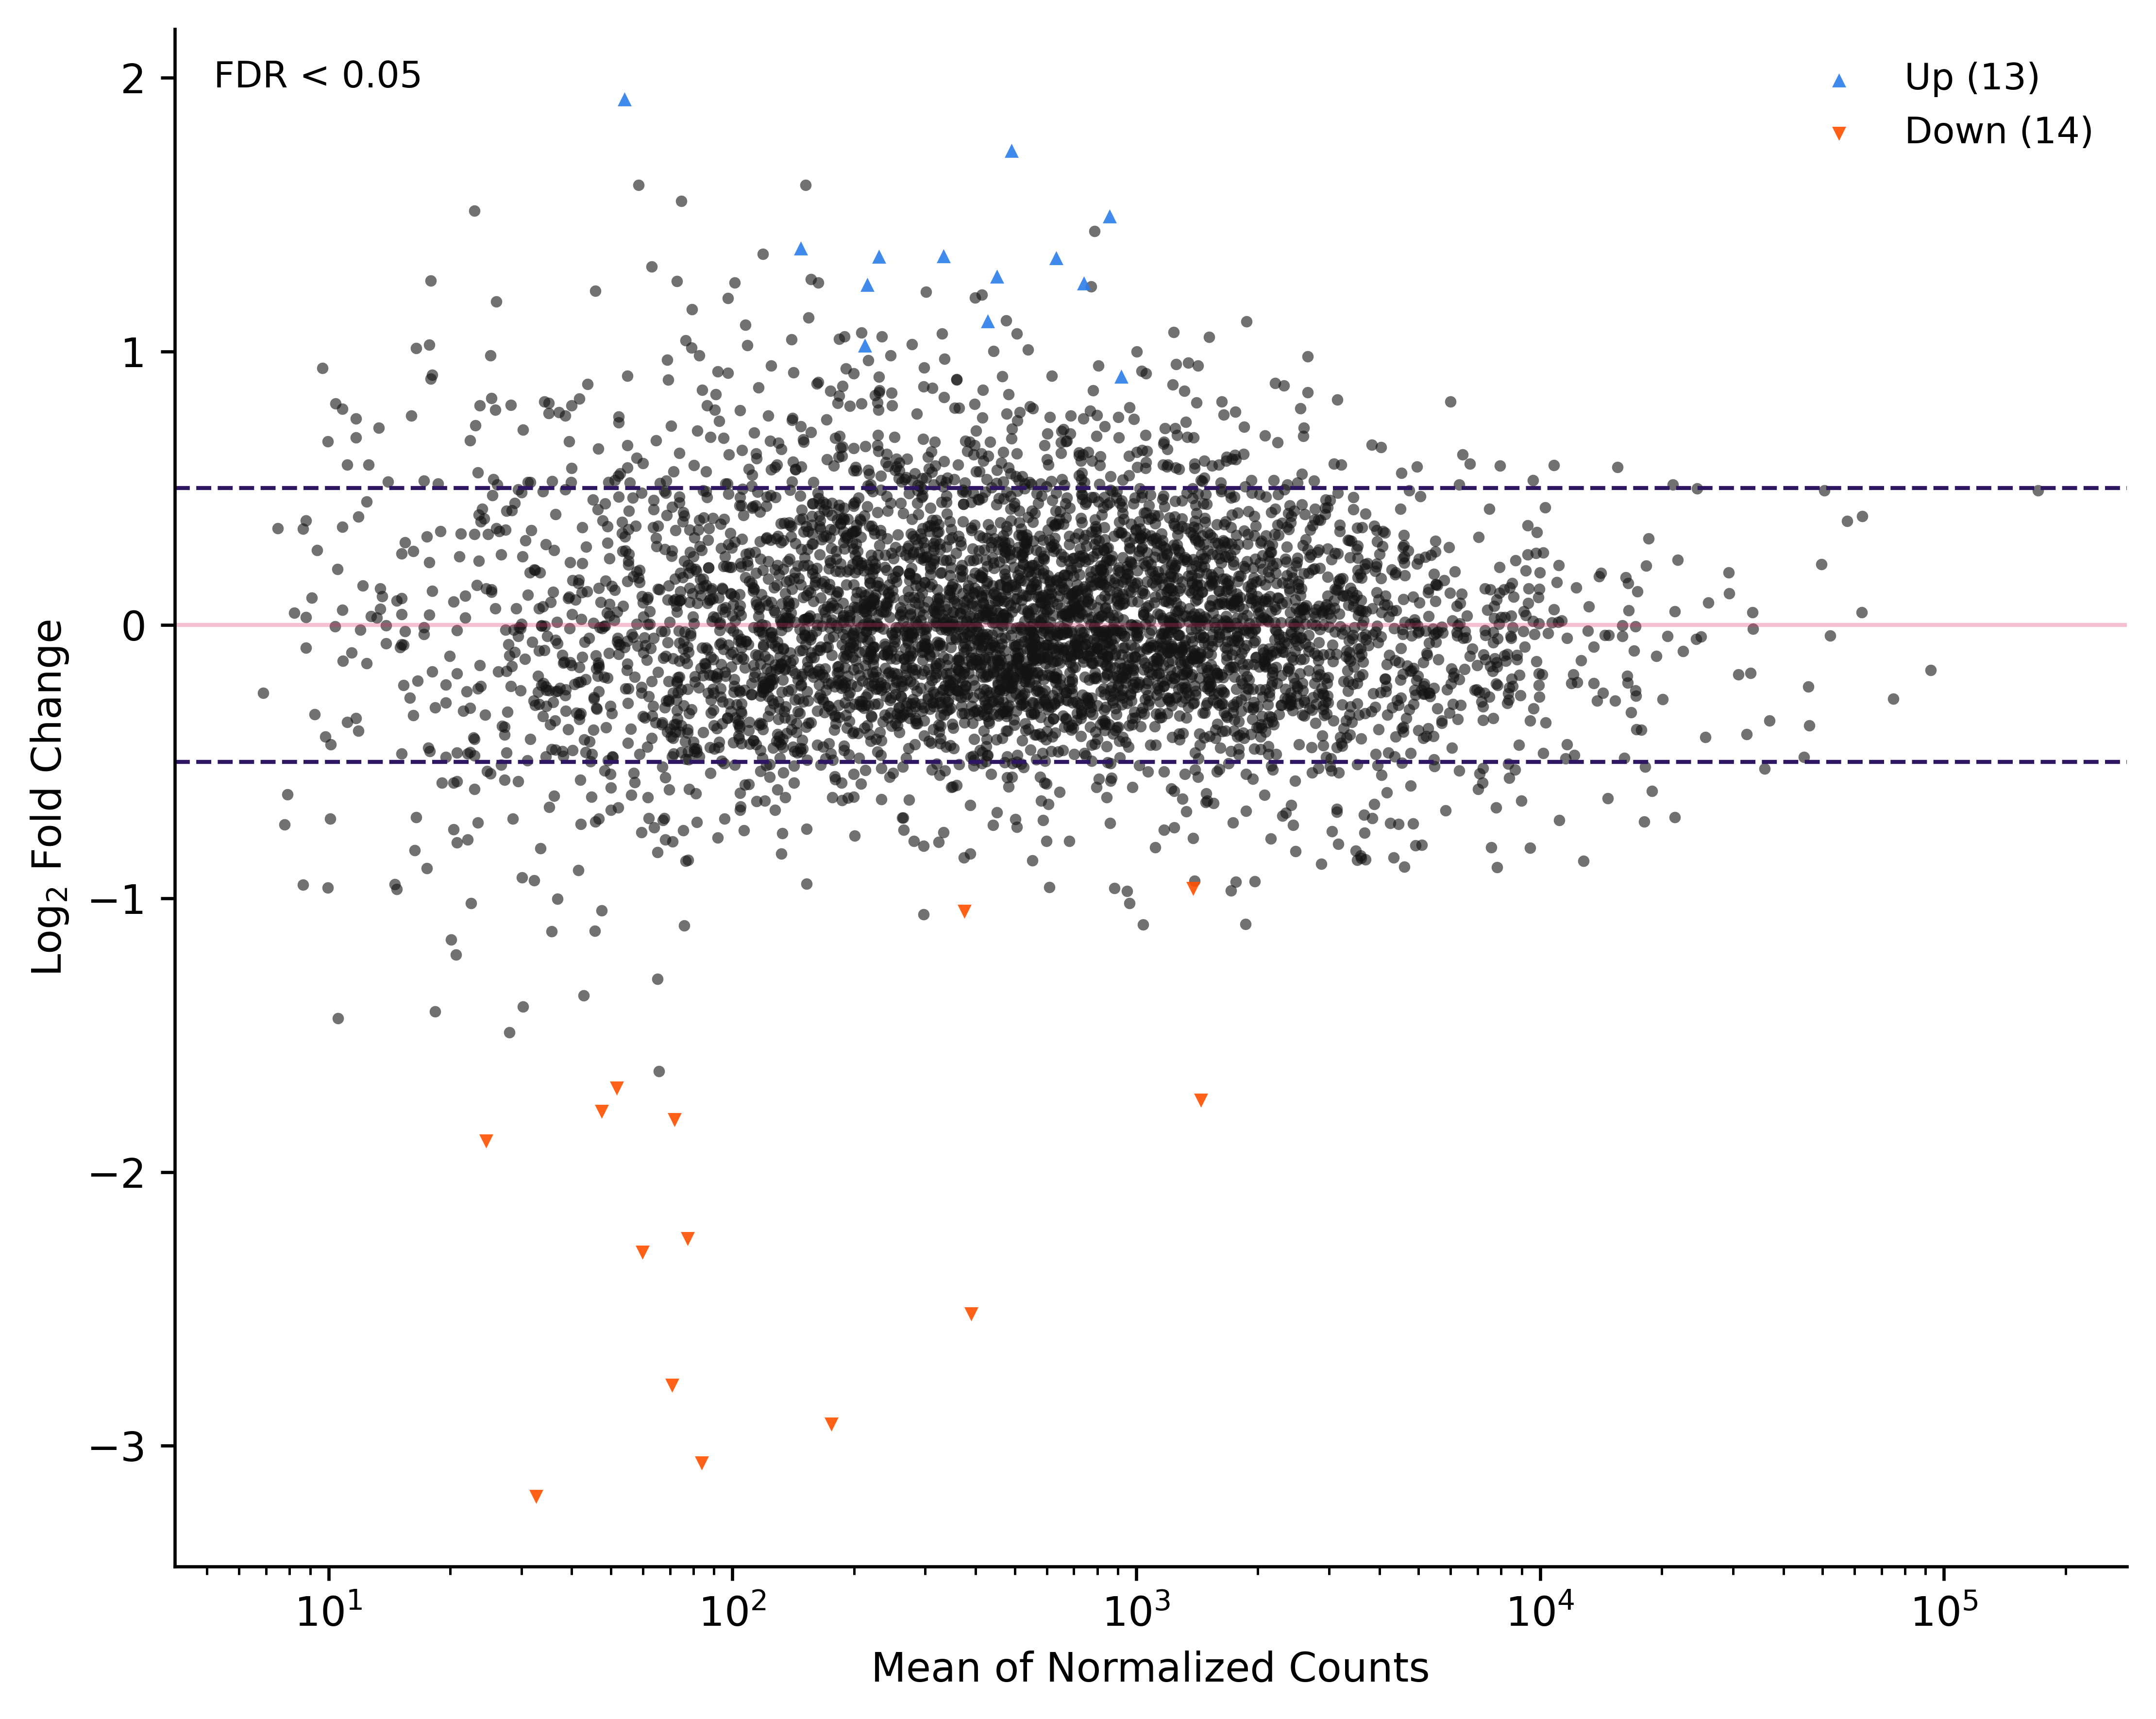

In [6]:
CSV_PATH   = "../data/output/edger_results.csv"
LFC_THR    = 0.5        # draw horizontal lines at ± this log2FC
FDR_THR    = 0.05       # significance threshold (if FDR/padj present)
TOP_LABELS = 10         # label this many genes total (split up/down)
POINT_SIZE = 8
# -------------------------------

def bh_adjust(pvals: np.ndarray) -> np.ndarray:
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranks = np.arange(1, n + 1)
    adj = np.empty_like(p)
    adj[order] = np.minimum.accumulate((p[order] * n / ranks)[::-1])[::-1]
    return np.clip(adj, 0, 1)

df = pd.read_csv(CSV_PATH)

# columns
gene_col = "name" if "name" in df.columns else df.columns[0]
lfc_col  = "log2FoldChange" if "log2FoldChange" in df.columns else ("logFC" if "logFC" in df.columns else None)
if lfc_col is None:
    if "foldChange" in df.columns:
        df["__log2FC__"] = np.log2(pd.to_numeric(df["foldChange"], errors="coerce"))
        lfc_col = "__log2FC__"
    else:
        raise ValueError("No log2FC/logFC/foldChange column found.")

padj_col = next((c for c in ["FDR","padj","PAdj"] if c in df.columns), None)
p_col    = next((c for c in ["PValue","pvalue","pval","p"] if c in df.columns), None)

# try to find per-sample normalized counts (columns added at the end in many pipelines)
known_meta = {
    gene_col, lfc_col, "log2FoldChange", "logFC", "foldChange",
    "baseMean","baseMeanA","baseMeanB","lfcSE","stat","PValue","pvalue","PAdj",
    "FDR","padj","falsePos"
}
numdf = df.select_dtypes(include=[np.number]).copy()
norm_cols = [c for c in numdf.columns if c not in known_meta]

if len(norm_cols) >= 2:
    mean_norm = numdf[norm_cols].mean(axis=1)
elif "baseMean" in df.columns:
    mean_norm = pd.to_numeric(df["baseMean"], errors="coerce")
else:
    raise ValueError("Could not find normalized counts (nor baseMean).")

# vectors
genes = df[gene_col].astype(str).to_numpy()
lfc   = pd.to_numeric(df[lfc_col], errors="coerce").to_numpy()

if padj_col:
    padj = pd.to_numeric(df[padj_col], errors="coerce").to_numpy()
elif p_col:
    padj = bh_adjust(pd.to_numeric(df[p_col], errors="coerce").to_numpy())
else:
    padj = np.full(lfc.shape, np.nan)  # no p-values available

# clean
valid = np.isfinite(mean_norm) & np.isfinite(lfc)
if np.isfinite(padj).any():
    valid &= np.isfinite(padj)
mean_norm, lfc, padj, genes = mean_norm[valid], lfc[valid], padj[valid], genes[valid]

# masks
sig = np.isfinite(padj) & (padj < FDR_THR)
up  = sig & (lfc >=  LFC_THR)
dn  = sig & (lfc <= -LFC_THR)
ns  = ~(up | dn)

# plot
fig, ax = plt.subplots(figsize=(7.5, 6))
# all points
ax.scatter(mean_norm[ns], lfc[ns], s=POINT_SIZE, alpha=0.6, linewidths=0, color="#131313")
# overlay significant (different markers; no explicit colors)
ax.scatter(mean_norm[up], lfc[up], s=POINT_SIZE+4, marker="^", alpha=0.9, linewidths=0, label=f"Up ({up.sum()})", color="#2a7de9")
ax.scatter(mean_norm[dn], lfc[dn], s=POINT_SIZE+4, marker="v", alpha=0.9, linewidths=0, label=f"Down ({dn.sum()})", color="#ff5000")

# axes, guides
ax.set_xscale("log")
ax.axhline(0,       ls="-",  lw=1, color="#DE316B4D")
ax.axhline(LFC_THR, ls="--", lw=1, color="#2E1760")
ax.axhline(-LFC_THR,ls="--", lw=1, color="#2E1760")
if np.isfinite(padj).any():
    ax.text(0.02, 0.98, f"FDR < {0.05}", transform=plt.gca().transAxes, va="top", ha="left", fontsize=9)

ax.set_xlabel("Mean of Normalized Counts")
ax.set_ylabel(r"${\rm Log}_{2}$ Fold Change")
# ax.title("MA plot")
ax.legend(frameon=False, fontsize=9, loc="upper right")

# label top genes (split up/down) without changing colors
def label_top(mask, k):
    idx = np.where(mask)[0]
    if idx.size == 0 or k <= 0:
        return
    order = np.lexsort((-np.abs(lfc[idx]), padj[idx]))  # rank: low FDR, large |LFC|
    for i in idx[order[:min(k, idx.size)]]:
        ax.annotate(genes[i], (mean_norm[i], lfc[i]),
                     xytext=(3, 1), textcoords="offset points", fontsize=8)

k_each = TOP_LABELS // 2
# label_top(up, k_each + (TOP_LABELS % 2))
# label_top(dn, k_each)

dotted_spines(ax)

plt.tight_layout()
plt.savefig("../data/output/volcano.png", dpi=300)
plt.savefig("../data/output/volcano.pdf")
plt.show()